# Real Estate Sales: Booking Cancellations, Pricing and Buyer Segments
**Author:** Atul Iwale · **Project 11** of the AEC Fieldwork portfolio (machine-learning upgrade)

**Business questions**
1. **Cancellations:** 45 days after a flat is booked, which bookings are likely to cancel within a year, so the CRM team can step in (loan help, payment plan, a site visit)?
2. **Pricing:** what will each unsold flat actually fetch, after the discount the market demands?
3. **Buyers:** what kinds of buyers does the developer really sell to?

The first version of this project reproduced two labelled booking patterns with fixed rules. This version uses a residential sales CRM for 8 launches, with 2,159 bookings and 760 unsold flats, to *predict*.

**Contents**
1. Load and audit the data
2. Cancellations: who cancels and why
3. Features known 45 days after booking
4. Split by booking date
5. Classifiers: Logistic Regression, KNN, SVM, Naive Bayes, Decision Tree, Random Forest, XGBoost
6. Results and the CRM call list
7. Explaining the risk (odds ratios)
8. Pricing: what will unsold flats fetch? (Ridge, KNN, SVR, Random Forest, XGBoost)
9. Buyer segments (K-means clustering)
10. Live cancellation risk and inventory value (August 2026)
11. Export for the web app

In [1]:
import warnings, json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, silhouette_score
from sklearn.calibration import calibration_curve
import xgboost as xgb
pd.set_option('display.width', 170); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
RS = 11
DATA = '../data/11_Real_Estate_Sales_v2.xlsx'

## 1. Load and audit the data

In [2]:
import numpy as np, pandas as pd
DATA_DATE = pd.Timestamp('2026-08-31')

def load(path):
    x = pd.read_excel(path, sheet_name=None)
    return x

def bookings(x):
    B = x['fact_booking_re'].merge(x['dim_unit_re'], on='unit_id').merge(x['dim_buyer'], on='buyer_id').merge(x['dim_project_re'][['project_id', 'project_name', 'city', 'launch_month']], on='project_id')
    B['booking_date'] = pd.to_datetime(B.booking_date); B['cancel_date'] = pd.to_datetime(B.cancel_date); B['launch_month'] = pd.to_datetime(B.launch_month)
    idx = x['city_price_index'].copy(); idx['month'] = pd.to_datetime(idx.month); idx = idx.set_index('month')
    m = B.booking_date.dt.to_period('M').dt.to_timestamp()
    B['market_6m_change'] = [idx.loc[mm, f'{c}_index'] / idx.loc[mm - pd.DateOffset(months=6), f'{c}_index'] - 1 for mm, c in zip(m, B.city)]
    B['months_since_launch'] = (B.booking_date - B.launch_month).dt.days / 30.4
    B['emi_to_income'] = B.agreement_value * B.ltv_pct / 100 * .0087 * 12 / 1e5 / B.annual_income_lakh
    B['ticket_cr'] = B.agreement_value / 1e7
    B['price_vs_list'] = B.achieved_rate_psf / (B.list_rate_psf + B.floor_rise_psf + B.plc_psf) - 1
    B['loan_status'] = np.select([B.home_loan == 'No', B.loan_sanctioned_at_booking == 'Yes'], ['No loan', 'Loan sanctioned'], 'Loan not yet sanctioned')
    B['age_band_n'] = B.age_band.map({'25-34': 0, '35-44': 1, '45-54': 2, '55+': 3})
    # outcome: cancelled within 365 days of booking (all cancellations here happen after day 45)
    B['matured'] = B.booking_date <= DATA_DATE - pd.Timedelta(days=365)
    B['y'] = (B.cancel_date.notna() & ((B.cancel_date - B.booking_date).dt.days <= 365)).astype(int)
    return B

NUM = ['emi_to_income', 'booking_amount_pct', 'discount_pct', 'first_demand_days_late', 'site_visits', 'days_first_visit_to_booking', 'ltv_pct', 'annual_income_lakh', 'ticket_cr',
       'market_6m_change', 'months_since_launch', 'price_vs_list', 'floor', 'age_band_n']
CAT = ['buyer_type', 'channel', 'payment_plan', 'unit_type', 'loan_status', 'residence', 'co_applicant', 'existing_customer', 'project_id']

x = load(DATA)
for k, v in x.items(): print(f'{k:20s} {v.shape[0]:>6,} rows x {v.shape[1]} cols')
B = bookings(x)
fb = x['fact_booking_re']
checks = {
  'every booking joins to a unit, buyer and project': len(B) == len(fb),
  'a unit has at most one booking': fb.unit_id.is_unique,
  'agreement value = achieved rate x carpet area': (fb.agreement_value - B.set_index('booking_id').loc[fb.booking_id].eval('achieved_rate_psf * carpet_area_sqft').values).abs().max() <= 1,
  'achieved rate = (list + floor rise + PLC) x (1 - discount), 99% of bookings within 3%': (B.price_vs_list + B.discount_pct / 100).abs().quantile(.99) < .03,
  'cancellation dates fall 46-365 days after booking': ((B.cancel_date - B.booking_date).dt.days.dropna().between(46, 365)).all(),
  'unsold flag agrees with active bookings': set(x['dim_unit_re'].query("inventory_status == 'Sold'").unit_id) == set(B[B.status == 'Active'].unit_id),
}
for k, v in checks.items(): print('OK ' if v else 'FAIL', k)
print(f"\n{len(B):,} bookings worth Rs {B.agreement_value.sum() / 1e7:,.0f} crore across {B.project_id.nunique()} projects; {(x['dim_unit_re'].inventory_status == 'Unsold').sum()} flats unsold at 31 Aug 2026")

dim_project_re            8 rows x 11 cols
dim_unit_re           2,661 rows x 10 cols
dim_buyer             2,159 rows x 8 cols
fact_booking_re       2,159 rows x 23 cols
city_price_index         56 rows x 8 cols
price_list_monthly      291 rows x 3 cols
data_dictionary_v2       18 rows x 4 cols
OK  every booking joins to a unit, buyer and project
OK  a unit has at most one booking
OK  agreement value = achieved rate x carpet area
OK  achieved rate = (list + floor rise + PLC) x (1 - discount), 99% of bookings within 3%
OK  cancellation dates fall 46-365 days after booking
OK  unsold flag agrees with active bookings

2,159 bookings worth Rs 2,093 crore across 8 projects; 760 flats unsold at 31 Aug 2026


## 2. Cancellations: who cancels and why

1,723 bookings are at least a year old; 12.9% of them cancelled within the year (forfeiting 2% of the agreement value)


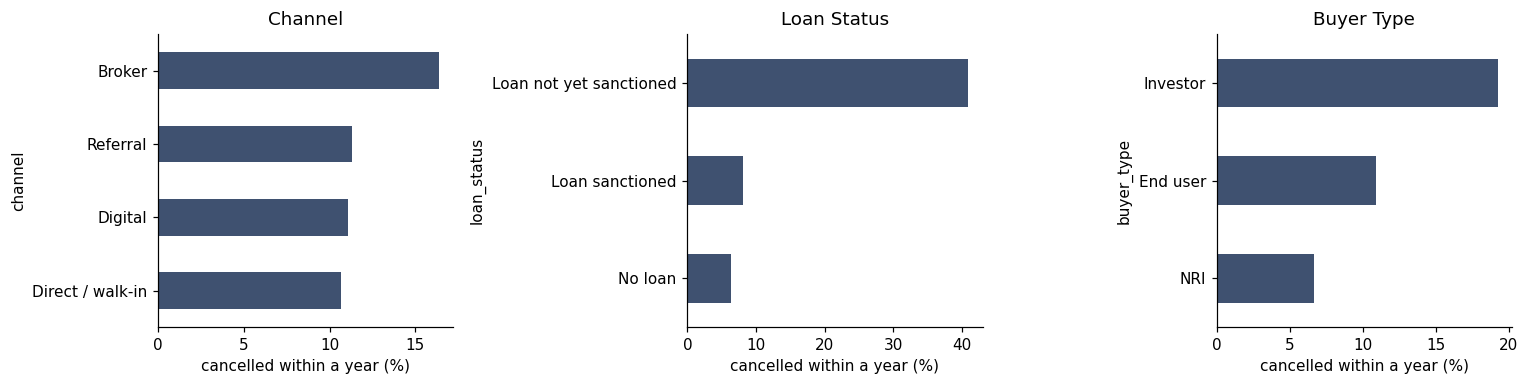

,cancellations
cancel_reason,
Financial difficulty,82
Construction delay,46
Home loan rejected,42
Better deal elsewhere,39
Family reasons,37
Investor exit / market slowdown,12


In [3]:
M = B[B.matured].copy()
print(f'{len(M):,} bookings are at least a year old; {M.y.mean():.1%} of them cancelled within the year (forfeiting 2% of the agreement value)')
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, c in zip(ax, ['channel', 'loan_status', 'buyer_type']):
    M.groupby(c).y.mean().sort_values().mul(100).plot.barh(ax=a, color='#3f5170'); a.set_xlabel('cancelled within a year (%)'); a.set_title(c.replace('_', ' ').title())
plt.tight_layout(); plt.show()
B.cancel_reason.value_counts().to_frame('cancellations')

The patterns match what sales teams see on the ground. Bookings without a loan sanction, where the EMI is a big share of income, bought through brokers with thin booking amounts, or bought by investors on subvention plans cancel far more often.

## 3. Features known 45 days after booking
The model scores a booking **45 days after booking**, once the first instalment demand is due. So it may use:
- the deal itself: discount, payment plan, booking amount, price vs the price list, ticket size,
- the buyer: type, income, age band, residence, co-applicant, repeat customer,
- affordability: loan status, loan-to-value, EMI-to-income,
- behaviour: site visits, days from first visit to booking, days late on the first demand,
- context: project, months since launch, and the city's resale-price trend over the last 6 months.

Nothing after day 45 is used. All cancellations in the data happen after day 45.

In [4]:
FEATS = NUM + CAT
M[FEATS].head(3).T

,0,1,2
emi_to_income,0.0,0.10126,0.24301
booking_amount_pct,9.0,8.7,12.0
discount_pct,1.9,3.6,4.8
first_demand_days_late,4,0,9
site_visits,3,1,4
days_first_visit_to_booking,2,8,12
ltv_pct,0,88,80
annual_income_lakh,34.1,77.3,21.4
ticket_cr,0.380351,0.851993,0.622656
market_6m_change,0.047343,0.047343,0.047343


## 4. Split by booking date
- **Train:** bookings before Jul 2024.
- **Validation:** Jul to Dec 2024, used to tune the models.
- **Test:** Jan to Aug 2025, used once. This period includes the 2025 slowdown in Noida and Hyderabad, so it is a realistic test of drift.
- **Live:** bookings from Sep 2025 onwards are scored but their outcome isn't known yet.

In [5]:
tr, va, te = [(M.booking_date < '2024-07-01').values, ((M.booking_date >= '2024-07-01') & (M.booking_date < '2025-01-01')).values, (M.booking_date >= '2025-01-01').values]
X, y = M[FEATS], M.y.values
pd.DataFrame({s: {'bookings': int(m.sum()), 'cancelled within a year': f'{y[m].mean():.1%}'} for s, m in zip(['train', 'validation', 'test'], [tr, va, te])}).T

,bookings,cancelled within a year
train,867,14.1%
validation,391,10.5%
test,465,12.9%


## 5. Classifiers
Each model is tuned on the validation half-year by PR-AUC, which suits a minority class (about 1 booking in 8 cancels). Numeric features are standardised for the distance- and margin-based models (KNN, SVM).

In [6]:
def pre(): return ColumnTransformer([('n', StandardScaler(), NUM), ('c', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT)])
grid = {
 'Logistic Regression': [LogisticRegression(C=c, max_iter=5000) for c in (.03, .1, .3, 1)],
 'K-Nearest Neighbours': [KNeighborsClassifier(n_neighbors=k, weights='distance') for k in (15, 31, 61, 101)],
 'SVM (RBF kernel)': [SVC(C=c, gamma=g, probability=True, random_state=RS) for c in (.3, 1, 3) for g in ('scale', .01)],
 'Naive Bayes': [GaussianNB(var_smoothing=v) for v in (1e-9, 1e-3, 1e-1)],
 'Decision Tree': [DecisionTreeClassifier(max_depth=d, min_samples_leaf=20, random_state=RS) for d in (3, 4, 5)],
 'Random Forest': [RandomForestClassifier(n_estimators=500, min_samples_leaf=l, max_features=f, n_jobs=4, random_state=RS) for l in (3, 8) for f in ('sqrt', .5)],
 'XGBoost': [xgb.XGBClassifier(n_estimators=n, max_depth=d, learning_rate=.05, subsample=.8, colsample_bytree=.8, min_child_weight=3, random_state=RS) for n in (150, 300) for d in (2, 3)],
}
models = {}
for name, cands in grid.items():
    best = None
    for m in cands:
        p = make_pipeline(pre(), m).fit(X[tr], y[tr]); s = average_precision_score(y[va], p.predict_proba(X[va])[:, 1])
        if best is None or s > best[1]: best = (p, s)
    models[name] = best[0]; print(f'{name:22s} validation PR-AUC {best[1]:.3f}')

Logistic Regression    validation PR-AUC 0.440
K-Nearest Neighbours   validation PR-AUC 0.401


SVM (RBF kernel)       validation PR-AUC 0.399
Naive Bayes            validation PR-AUC 0.408
Decision Tree          validation PR-AUC 0.322


Random Forest          validation PR-AUC 0.467


XGBoost                validation PR-AUC 0.473


## 6. Results on the test half-year (Jan to Aug 2025)
The CRM team can call a fixed share of new bookings each month. **Recall at top 20%** is the share of eventual cancellations found by calling the riskiest fifth.

In [7]:
P = {n: m.predict_proba(X[te])[:, 1] for n, m in models.items()}
yt = y[te]; vt = M.agreement_value.values[te]
def top_share(s, share):
    k = int(np.ceil(share * len(s))); return np.argsort(-s, kind='stable')[:k]
res = pd.DataFrame({n: {'ROC-AUC': roc_auc_score(yt, s), 'PR-AUC': average_precision_score(yt, s), 'Brier': brier_score_loss(yt, s),
                        'recall @ top 10%': yt[top_share(s, .1)].sum() / yt.sum(), 'recall @ top 20%': yt[top_share(s, .2)].sum() / yt.sum(),
                        'precision @ top 20%': yt[top_share(s, .2)].mean(),
                        'value at risk found @ 20%': vt[top_share(s, .2)][yt[top_share(s, .2)] == 1].sum() / vt[yt == 1].sum()} for n, s in P.items()}).T.sort_values('PR-AUC', ascending=False)
BEST = res.index[0]
print(f'Test: {len(yt)} bookings, {yt.sum()} cancelled ({yt.mean():.1%}). Best by PR-AUC: {BEST}')
res.round(3)

Test: 465 bookings, 60 cancelled (12.9%). Best by PR-AUC: Random Forest


,ROC-AUC,PR-AUC,Brier,recall @ top 10%,recall @ top 20%,precision @ top 20%,value at risk found @ 20%
Random Forest,0.825,0.518,0.088,0.383,0.650,0.419,0.670
XGBoost,0.811,0.506,0.088,0.367,0.600,0.387,0.623
Naive Bayes,0.827,0.488,0.100,0.433,0.650,0.419,0.692
Logistic Regression,0.816,0.472,0.089,0.450,0.600,0.387,0.627
SVM (RBF kernel),0.763,0.429,0.095,0.383,0.583,0.376,0.604
K-Nearest Neighbours,0.767,0.401,0.101,0.433,0.583,0.376,0.630
Decision Tree,0.789,0.367,0.100,0.333,0.467,0.301,0.440


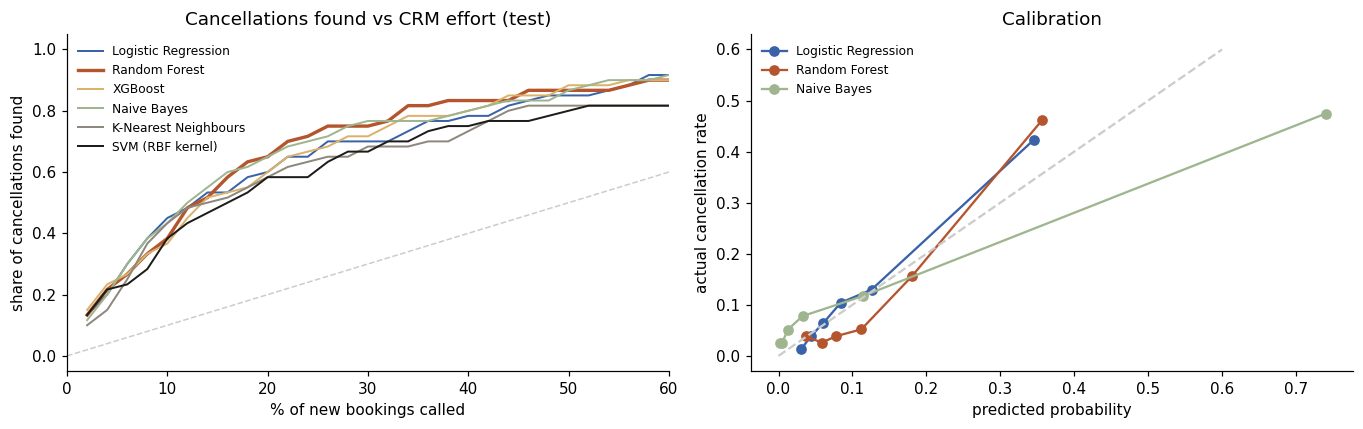

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
shares = np.linspace(.02, .6, 30); cols = {'Logistic Regression': '#3a62a8', 'Random Forest': '#b4552e', 'XGBoost': '#d9b36b', 'Naive Bayes': '#9fb58f', 'K-Nearest Neighbours': '#8e887c', 'SVM (RBF kernel)': '#1e1c18'}
for n, c in cols.items(): ax[0].plot(shares * 100, [yt[top_share(P[n], s)].sum() / yt.sum() for s in shares], color=c, lw=2.2 if n == BEST else 1.3, label=n)
ax[0].plot([0, 100], [0, 1], color='#ccc', ls='--', lw=1); ax[0].set_xlim(0, 60); ax[0].set_xlabel('% of new bookings called'); ax[0].set_ylabel('share of cancellations found'); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title('Cancellations found vs CRM effort (test)')
for n, c in [('Logistic Regression', '#3a62a8'), ('Random Forest', '#b4552e'), ('Naive Bayes', '#9fb58f')]:
    fp, mp = calibration_curve(yt, P[n], n_bins=6, strategy='quantile'); ax[1].plot(mp, fp, marker='o', color=c, label=n)
ax[1].plot([0, .6], [0, .6], color='#ccc', ls='--'); ax[1].set_xlabel('predicted probability'); ax[1].set_ylabel('actual cancellation rate'); ax[1].set_title('Calibration'); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

- **Simple models hold their own.** With under 900 training bookings, Logistic Regression, Naive Bayes and Random Forest land close together. Heavier models have little room to shine, and a well-built logistic model is easier to explain to a sales head.
- **KNN and SVM rank worse here.** Many one-hot categories make distances less meaningful, and the class imbalance hurts margin-based scores. Both are useful as a check, not as the main model.
- **The Decision Tree** is readable but coarse. Its top splits (below) are exactly the questions a CRM manager would ask.

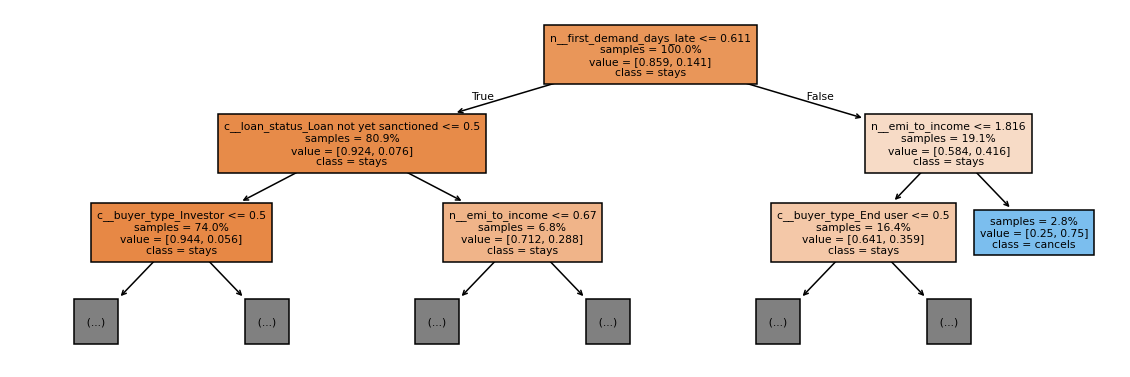

In [9]:
fig, ax = plt.subplots(figsize=(13, 4.2))
dt = models['Decision Tree']; plot_tree(dt[-1], feature_names=dt[0].get_feature_names_out(), class_names=['stays', 'cancels'], max_depth=2, filled=True, impurity=False, proportion=True, fontsize=7, ax=ax); plt.show()

## 7. Explaining the risk (odds ratios)
The logistic model says, in plain numbers, how much each factor multiplies the odds of cancelling, holding the others fixed.

In [10]:
lr = models['Logistic Regression']; names = lr[0].get_feature_names_out(); coef = lr[-1].coef_[0]
nice = lambda s: s.replace('n__', '').replace('c__', '').replace('_', ' ')
orr = pd.DataFrame({'feature': [nice(n) for n in names], 'odds ratio (per 1 SD or vs other groups)': np.exp(coef)}).sort_values('odds ratio (per 1 SD or vs other groups)')
pd.concat([orr.tail(8)[::-1], orr.head(5)]).round(2)

,feature,odds ratio (per 1 SD or vs other groups)
3,first demand days late,1.73
0,emi to income,1.44
15,buyer type Investor,1.40
28,loan status Loan not yet sanctioned,1.37
17,channel Broker,1.16
25,unit type 2 BHK,1.08
37,existing customer Yes,1.07
9,market 6m change,1.06
14,buyer type End user,0.72
29,loan status Loan sanctioned,0.76


## 8. Pricing: what will unsold flats fetch?
The price list says what a flat *should* sell for. The achieved rate depends on floor, view, deal type, how long the project has been selling, and the market. **Baseline:** price list, floor rise and PLC, less the average historical discount. The models learn the achieved rate per sq ft (log) from bookings before Jul 2025 and are tested on Jul 2025 to Aug 2026.

In [11]:
PNUM = ['list_rate_psf', 'floor_rise_psf', 'plc_psf', 'floor', 'carpet_area_sqft', 'months_since_launch', 'market_6m_change', 'booking_month']
PCAT = ['project_id', 'unit_type', 'facing', 'corner_unit', 'channel', 'payment_plan', 'buyer_type']
B['booking_month'] = B.booking_date.dt.month
ptr = (B.booking_date < '2025-07-01').values; pte = ~ptr
def ppre(): return ColumnTransformer([('n', StandardScaler(), PNUM), ('c', OneHotEncoder(handle_unknown='ignore', sparse_output=False), PCAT)])
ylog = np.log(B.achieved_rate_psf.values)
pgrid = {'Ridge regression': [RidgeCV(alphas=np.logspace(-3, 3, 25))], 'KNN regression': [KNeighborsRegressor(n_neighbors=k, weights='distance') for k in (5, 15, 30)],
         'SVR (RBF kernel)': [SVR(C=c, epsilon=.01) for c in (.3, 1, 3)], 'Random Forest': [RandomForestRegressor(n_estimators=400, min_samples_leaf=l, n_jobs=4, random_state=RS) for l in (2, 5)],
         'XGBoost': [xgb.XGBRegressor(n_estimators=n, max_depth=d, learning_rate=.05, subsample=.8, colsample_bytree=.8, random_state=RS) for n in (400, 800) for d in (3, 4)]}
cut = B.booking_date[ptr].quantile(.8)                                         # tune on the last 20% of the training period
itr, iva = ptr & (B.booking_date < cut).values, ptr & (B.booking_date >= cut).values
pmodels, prow = {}, {}
for name, cands in pgrid.items():
    best = None
    for m in cands:
        p = make_pipeline(ppre(), m).fit(B.loc[itr, PNUM + PCAT], ylog[itr]); e = np.mean(np.abs(np.exp(p.predict(B.loc[iva, PNUM + PCAT])) / B.achieved_rate_psf[iva] - 1))
        if best is None or e < best[1]: best = (m, e)
    pmodels[name] = make_pipeline(ppre(), best[0]).fit(B.loc[ptr, PNUM + PCAT], ylog[ptr])
avg_disc = B.discount_pct[ptr].mean()
PP = {'Price list less average discount': ((B.list_rate_psf + B.floor_rise_psf + B.plc_psf) * (1 - avg_disc / 100)).values[pte]}
PP.update({n: np.exp(m.predict(B.loc[pte, PNUM + PCAT])) for n, m in pmodels.items()})
act = B.achieved_rate_psf.values[pte]
pres = pd.DataFrame({n: {'MAPE %': np.mean(np.abs(p / act - 1)) * 100, 'within ±2%': np.mean(np.abs(p / act - 1) <= .02), 'bias %': np.mean(p / act - 1) * 100} for n, p in PP.items()}).T.sort_values('MAPE %')
PBEST = [n for n in pres.index if n in pmodels][0]
print(f'test bookings: {pte.sum()} | best model: {PBEST}'); pres.round(3)

test bookings: 550 | best model: XGBoost


,MAPE %,within ±2%,bias %
XGBoost,2.015,0.575,-0.164
Price list less average discount,2.272,0.538,1.196
Random Forest,2.784,0.464,0.352
Ridge regression,3.548,0.402,1.865
SVR (RBF kernel),3.909,0.338,0.361
KNN regression,9.591,0.104,-3.966


The price list alone is already a strong baseline, because developers price carefully. The model's gain comes from knowing *which* deals need a bigger discount: broker deals, down-payment plans, festive months, low and top floors, and projects that have been selling longer. KNN is poor here because distance treats a 10th-floor lake-view 3 BHK and a 10th-floor road-facing 2 BHK as close neighbours.

## 9. Buyer segments (K-means clustering)
Unsupervised clustering on how buyers buy: income, age, ticket size, loan-to-value, EMI burden, booking amount, site visits and days from first visit to booking. Buyer type is left out on purpose, to see whether investors emerge from behaviour alone.

In [12]:
B['log_income'] = np.log(B.annual_income_lakh); B['log_ticket'] = np.log(B.ticket_cr)
SEGF = ['log_income', 'age_band_n', 'log_ticket', 'ltv_pct', 'emi_to_income', 'booking_amount_pct', 'site_visits', 'days_first_visit_to_booking']
seg_sc = StandardScaler().fit(B[SEGF]); Zs = seg_sc.transform(B[SEGF])
sil = {k: silhouette_score(Zs, KMeans(k, n_init=10, random_state=RS).fit_predict(Zs)) for k in range(3, 7)}
K = 5; km = KMeans(K, n_init=10, random_state=RS).fit(Zs); B['segment'] = km.labels_
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()}, '| chosen k =', K, '(silhouette is flat; 5 gives segments the sales team can act on)')
prof = B.groupby('segment').agg(bookings=('booking_id', 'size'), income_lakh=('annual_income_lakh', 'median'), ticket_cr=('ticket_cr', 'median'), ltv_pct=('ltv_pct', 'median'),
                                emi_to_income=('emi_to_income', 'median'), site_visits=('site_visits', 'median'), days_to_book=('days_first_visit_to_booking', 'median'),
                                investor_or_nri=('buyer_type', lambda s: (s != 'End user').mean()), cancel_rate=('y', lambda s: s[B.loc[s.index, 'matured']].mean()))
def seg_name(r):
    if r.ltv_pct < 20: return 'Cash buyers (mostly investors and NRIs)'
    if r.emi_to_income > .35: return 'Stretched buyers (high EMI)'
    if r.site_visits >= 4: return 'Careful researchers (many visits)'
    if r.income_lakh > 45: return 'Affluent upgraders'
    return 'Budget first-home buyers'
prof.insert(0, 'segment_name', [seg_name(r) for r in prof.itertuples()])
prof.sort_values('cancel_rate', ascending=False).round(2)

silhouette by k: {3: 0.168, 4: 0.149, 5: 0.142, 6: 0.138} | chosen k = 5 (silhouette is flat; 5 gives segments the sales team can act on)


,segment_name,bookings,income_lakh,ticket_cr,ltv_pct,emi_to_income,site_visits,days_to_book,investor_or_nri,cancel_rate
segment,,,,,,,,,,
1,Stretched buyers (high EMI),313,22.50,1.05,79.0,0.41,3.0,14.0,0.27,0.28
3,Budget first-home buyers,475,28.50,0.65,78.0,0.19,2.0,11.0,0.29,0.14
2,Careful researchers (many visits),322,37.35,0.85,76.0,0.20,5.0,39.5,0.31,0.11
0,Affluent upgraders,484,53.00,1.11,78.0,0.17,2.0,11.0,0.29,0.11
4,Cash buyers (mostly investors and NRIs),565,35.10,0.91,0.0,0.00,3.0,13.0,0.66,0.06


Segments give the sales team a shared language. *Stretched buyers* cancel far more often than the rest and need loan pre-approval before booking. *Cash buyers* rarely cancel, and they turn out to be mostly investors and NRIs even though buyer type was never an input.

## 10. Live cancellation risk and inventory value (August 2026)

In [13]:
LIVE = B[(B.booking_date >= '2025-09-01') & (B.booking_date <= pd.Timestamp('2026-08-31') - pd.Timedelta(days=45)) & (B.status == 'Active')].copy()
FINAL = models['Logistic Regression']                      # interpretable and within reach of the best model; runs in the browser
LIVE['risk'] = FINAL.predict_proba(LIVE[FEATS])[:, 1]; LIVE['risk_best'] = models[BEST].predict_proba(LIVE[FEATS])[:, 1]
n20 = int(np.ceil(.2 * len(LIVE)))
print(f'{len(LIVE)} active bookings from the last 12 months; the riskiest {n20} (20%) hold Rs {LIVE.nlargest(n20, "risk").agreement_value.sum() / 1e7:.1f} crore of agreement value')
LIVE.nlargest(8, 'risk')[['booking_id', 'project_name', 'unit_type', 'buyer_type', 'channel', 'loan_status', 'emi_to_income', 'first_demand_days_late', 'risk', 'risk_best']].round(3)

356 active bookings from the last 12 months; the riskiest 72 (20%) hold Rs 71.7 crore of agreement value


,booking_id,project_name,unit_type,buyer_type,channel,loan_status,emi_to_income,first_demand_days_late,risk,risk_best
2091,BKV02092,Riverside Towers,2 BHK,Investor,Digital,Loan not yet sanctioned,0.668,45,0.707,0.588
1836,BKV01837,Metro One,2 BHK,End user,Broker,Loan not yet sanctioned,0.505,45,0.691,0.525
1803,BKV01804,Riverside Towers,2 BHK,Investor,Direct / walk-in,Loan not yet sanctioned,0.358,45,0.602,0.522
1830,BKV01831,Green Acres,3 BHK,Investor,Referral,Loan not yet sanctioned,0.439,45,0.553,0.538
1782,BKV01783,Green Acres,3 BHK,Investor,Broker,Loan not yet sanctioned,0.254,36,0.507,0.419
1827,BKV01828,Metro One,2 BHK,End user,Referral,Loan not yet sanctioned,0.201,45,0.502,0.410
1780,BKV01781,Riverside Towers,3 BHK,Investor,Direct / walk-in,Loan not yet sanctioned,0.270,45,0.481,0.430
1775,BKV01776,Riverside Towers,2 BHK,End user,Referral,Loan sanctioned,0.528,45,0.466,0.358


In [14]:
# price every unsold flat at the August 2026 price list, for a standard deal (walk-in, construction-linked, end user)
U = x['dim_unit_re']; PL = x['price_list_monthly'].query("month == '2026-08-01'").set_index('project_id').base_rate_psf
proj = x['dim_project_re'].set_index('project_id'); idxm = x['city_price_index'].assign(month=lambda z: pd.to_datetime(z.month)).set_index('month')
plc = B.groupby(['project_id', 'facing', 'corner_unit']).plc_psf.median()
UN = U[U.inventory_status == 'Unsold'].copy()
UN['list_rate_psf'] = UN.project_id.map(PL); UN['floor_rise_psf'] = 40 * (UN.floor - 5).clip(lower=0)
UN['plc_psf'] = [plc.get((p, f, c), np.nan) for p, f, c in zip(UN.project_id, UN.facing, UN.corner_unit)]
UN['plc_psf'] = UN.plc_psf.fillna(UN.groupby('facing').plc_psf.transform('median')).fillna(0)
aug = pd.Timestamp('2026-08-01')
UN['months_since_launch'] = [(aug - pd.Timestamp(proj.launch_month[p])).days / 30.4 for p in UN.project_id]
UN['market_6m_change'] = [idxm.loc[aug, f'{proj.city[p]}_index'] / idxm.loc[aug - pd.DateOffset(months=6), f'{proj.city[p]}_index'] - 1 for p in UN.project_id]
UN['booking_month'] = 8; UN['channel'] = 'Direct / walk-in'; UN['payment_plan'] = 'Construction-linked'; UN['buyer_type'] = 'End user'
UN['pred_psf'] = np.exp(pmodels[PBEST].predict(UN[PNUM + PCAT])); UN['list_total_psf'] = UN.list_rate_psf + UN.floor_rise_psf + UN.plc_psf
UN['pred_value'] = UN.pred_psf * UN.carpet_area_sqft; UN['implied_discount_pct'] = (1 - UN.pred_psf / UN.list_total_psf) * 100
inv = UN.groupby('project_id').agg(unsold=('unit_id', 'size'), list_value_cr=('list_total_psf', lambda s: (s * UN.loc[s.index, 'carpet_area_sqft']).sum() / 1e7),
                                   predicted_value_cr=('pred_value', lambda s: s.sum() / 1e7), implied_discount_pct=('implied_discount_pct', 'mean'))
inv.insert(0, 'project', inv.index.map(proj.project_name)); print(f"Unsold inventory: {len(UN)} flats, list value Rs {inv.list_value_cr.sum():.0f} cr, expected to realise Rs {inv.predicted_value_cr.sum():.0f} cr"); inv.round(1)

Unsold inventory: 760 flats, list value Rs 946 cr, expected to realise Rs 890 cr


,project,unsold,list_value_cr,predicted_value_cr,implied_discount_pct
project_id,,,,,
RPR01,Skyline Residences,69,85.9,81.3,5.6
RPR02,Harbour Heights,92,158.5,144.0,9.1
RPR03,Green Acres,94,122.0,112.2,8.1
RPR04,Lakeview Enclave,85,111.3,101.9,8.6
RPR05,Metro One,130,195.3,185.3,5.2
RPR06,Palm Grove,66,53.8,51.3,4.9
RPR07,Riverside Towers,109,120.4,115.5,4.2
RPR08,Aurum Bay,115,98.4,98.6,-0.2


## 11. Export for the web app

In [15]:
def dump(m): return [json.loads(t_) for t_ in m.get_booster().get_dump(dump_format='json')]
def base_score(m): return float(json.loads(m.get_booster().save_config())['learner']['learner_model_param']['base_score'].strip('[]'))
ct = FINAL[0]; sc_ = ct.named_transformers_['n']; oh = ct.named_transformers_['c']
lr_exp = {'num': NUM, 'mean': sc_.mean_.tolist(), 'scale': sc_.scale_.tolist(), 'cat': CAT, 'cats': [c.tolist() for c in oh.categories_], 'coef': FINAL[-1].coef_[0].tolist(), 'intercept': float(FINAL[-1].intercept_[0])}
pm = pmodels['XGBoost']; pct_, poh = pm[0].named_transformers_['n'], pm[0].named_transformers_['c']
price_exp = {'num': PNUM, 'mean': pct_.mean_.tolist(), 'scale': pct_.scale_.tolist(), 'cat': PCAT, 'cats': [c.tolist() for c in poh.categories_], 'fnames': pm[0].get_feature_names_out().tolist(),
             'base_score': base_score(pm[-1]), 'trees': dump(pm[-1])}
rec = lambda df, cols: [{c: (None if pd.isna(v) else (v.item() if hasattr(v, 'item') else v)) for c, v in zip(cols, r)} for r in df[cols].itertuples(index=False)]
LCOLS = ['booking_id', 'booking_date', 'project_id', 'project_name', 'unit_id', 'unit_type', 'buyer_name', 'agreement_value', 'risk', 'risk_best'] + [c for c in FEATS if c not in ('project_id', 'unit_type')]
live_out = LIVE.assign(booking_date=LIVE.booking_date.dt.strftime('%Y-%m-%d'))
UCOLS = ['unit_id', 'project_id', 'tower', 'floor', 'unit_type', 'carpet_area_sqft', 'facing', 'corner_unit'] + [c for c in PNUM + PCAT if c not in ('project_id', 'unit_type', 'floor', 'carpet_area_sqft', 'facing', 'corner_unit')] + ['pred_psf', 'list_total_psf']
export = {'lr': lr_exp, 'price': price_exp, 'live': rec(live_out, LCOLS), 'unsold': rec(UN, UCOLS),
          'results': res.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'), 'best': BEST,
          'pres': pres.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'), 'inventory': inv.reset_index().to_dict(orient='records'),
          'segments': prof.reset_index().to_dict(orient='records'), 'odds': orr.to_dict(orient='records'),
          'projects': x['dim_project_re'].to_dict(orient='records'), 'plc': {f'{p}|{f}|{c}': float(v) for (p, f, c), v in plc.items()},
          'test_check': [{'x': {c: (v.item() if hasattr(v, 'item') else v) for c, v in r.items()}, 'p': float(p)} for r, p in zip(M.loc[te, FEATS].head(60).to_dict(orient='records'), FINAL.predict_proba(M.loc[te, FEATS].head(60))[:, 1])],
          'price_check': [{'x': {c: (v.item() if hasattr(v, 'item') else v) for c, v in r.items()}, 'p': float(p)} for r, p in zip(B.loc[pte, PNUM + PCAT].head(60).to_dict(orient='records'), np.exp(pm.predict(B.loc[pte, PNUM + PCAT].head(60))))],
          'n_test': int(te.sum()), 'test_rate': float(yt.mean()), 'n_train': int(tr.sum())}
with open('../model/sales_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'), allow_nan=False, default=str)
print('Exported: logistic model,', len(price_exp['trees']), 'price trees,', len(export['live']), 'live bookings,', len(export['unsold']), f"unsold flats | {os.path.getsize('../model/sales_export.json') / 1e6:.2f} MB")

Exported: logistic model, 800 price trees, 356 live bookings, 760 unsold flats | 1.51 MB


## Summary
- **Data:** 8 residential launches, 2,661 flats, 2,159 bookings (Rs 2,093 crore) and 760 unsold flats, with buyer, deal, loan and payment behaviour, a monthly price list and city price indices.
- **Cancellations:** seven classifiers compared on a later half-year, scored 45 days after booking. The simpler models (logistic regression, Naive Bayes, Random Forest) perform best. Calling the riskiest 20% of new bookings finds most eventual cancellations (section 6), and the odds ratios show why: no loan sanction, a high EMI-to-income ratio, late first payment, a thin booking amount, broker deals and investors in a softening market.
- **Pricing:** XGBoost predicts the achieved rate per sq ft better than the price list less the average discount. It prices every unsold flat and shows the discount each project is likely to need.
- **Segments:** K-means on buying behaviour finds five buyer groups. Stretched buyers cancel several times as often as cash buyers.
- **Honest limits:** the data is synthetic. With under 900 training bookings the model ranking is fragile, so retrain every quarter. An intervention's effect on cancellations would need an A/B test before claiming savings.